In [3]:
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import pandas as pd

plotting.setup_mpl()

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#2021 schedule
schedule = fastf1.get_event_schedule(2021)
schedule

,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
0,0,Bahrain,Bahrain,FORMULA 1 ARAMCO PRE-SEASON TESTING 2021,2021-03-14,Pre-Season Test,testing,Practice 1,2021-03-12 10:00:00+03:00,2021-03-12 07:00:00,...,Practice 3,2021-03-14 10:00:00+03:00,2021-03-14 07:00:00,None,NaT,NaT,None,NaT,NaT,False
1,1,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2021,2021-03-28,Bahrain Grand Prix,conventional,Practice 1,2021-03-26 14:30:00+03:00,2021-03-26 11:30:00,...,Practice 3,2021-03-27 15:00:00+03:00,2021-03-27 12:00:00,Qualifying,2021-03-27 18:00:00+03:00,2021-03-27 15:00:00,Race,2021-03-28 18:00:00+03:00,2021-03-28 15:00:00,True
2,2,Italy,Imola,FORMULA 1 PIRELLI GRAN PREMIO DEL MADE IN ITAL...,2021-04-18,Emilia Romagna Grand Prix,conventional,Practice 1,2021-04-16 11:00:00+02:00,2021-04-16 09:00:00,...,Practice 3,2021-04-17 11:00:00+02:00,2021-04-17 09:00:00,Qualifying,2021-04-17 14:00:00+02:00,2021-04-17 12:00:00,Race,2021-04-18 15:00:00+02:00,2021-04-18 13:00:00,True
3,3,Portugal,Portimão,FORMULA 1 HEINEKEN GRANDE PRÉMIO DE PORTUGAL 2021,2021-05-02,Portuguese Grand Prix,conventional,Practice 1,2021-04-30 11:30:00+01:00,2021-04-30 10:30:00,...,Practice 3,2021-05-01 12:00:00+01:00,2021-05-01 11:00:00,Qualifying,2021-05-01 15:00:00+01:00,2021-05-01 14:00:00,Race,2021-05-02 15:00:00+01:00,2021-05-02 14:00:00,True
4,4,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2021,2021-05-09,Spanish Grand Prix,conventional,Practice 1,2021-05-07 11:30:00+02:00,2021-05-07 09:30:00,...,Practice 3,2021-05-08 12:00:00+02:00,2021-05-08 10:00:00,Qualifying,2021-05-08 15:00:00+02:00,2021-05-08 13:00:00,Race,2021-05-09 15:00:00+02:00,2021-05-09 13:00:00,True
5,5,Monaco,Monte Carlo,FORMULA 1 GRAND PRIX DE MONACO 2021,2021-05-23,Monaco Grand Prix,conventional,Practice 1,2021-05-20 11:30:00+02:00,2021-05-20 09:30:00,...,Practice 3,2021-05-22 12:00:00+02:00,2021-05-22 10:00:00,Qualifying,2021-05-22 15:00:00+02:00,2021-05-22 13:00:00,Race,2021-05-23 15:00:00+02:00,2021-05-23 13:00:00,True
6,6,Azerbaijan,Baku,FORMULA 1 AZERBAIJAN GRAND PRIX 2021,2021-06-06,Azerbaijan Grand Prix,conventional,Practice 1,2021-06-04 12:30:00+04:00,2021-06-04 08:30:00,...,Practice 3,2021-06-05 13:00:00+04:00,2021-06-05 09:00:00,Qualifying,2021-06-05 16:00:00+04:00,2021-06-05 12:00:00,Race,2021-06-06 16:00:00+04:00,2021-06-06 12:00:00,True
7,7,France,Le Castellet,FORMULA 1 EMIRATES GRAND PRIX DE FRANCE 2021,2021-06-20,French Grand Prix,conventional,Practice 1,2021-06-18 11:30:00+02:00,2021-06-18 09:30:00,...,Practice 3,2021-06-19 12:00:00+02:00,2021-06-19 10:00:00,Qualifying,2021-06-19 15:00:00+02:00,2021-06-19 13:00:00,Race,2021-06-20 15:00:00+02:00,2021-06-20 13:00:00,True
8,8,Austria,Spielberg,FORMULA 1 BWT GROSSER PREIS DER STEIERMARK 2021,2021-06-27,Styrian Grand Prix,conventional,Practice 1,2021-06-25 11:30:00+02:00,2021-06-25 09:30:00,...,Practice 3,2021-06-26 12:00:00+02:00,2021-06-26 10:00:00,Qualifying,2021-06-26 15:00:00+02:00,2021-06-26 13:00:00,Race,2021-06-27 15:00:00+02:00,2021-06-27 13:00:00,True
9,9,Austria,Spielberg,FORMULA 1 BWT GROSSER PREIS VON ÖSTERREICH 2021,2021-07-04,Austrian Grand Prix,conventional,Practice 1,2021-07-02 11:30:00+02:00,2021-07-02 09:30:00,...,Practice 3,2021-07-03 12:00:00+02:00,2021-07-03 10:00:00,Qualifying,2021-07-03 15:00:00+02:00,2021-07-03 13:00:00,Race,2021-07-04 15:00:00+02:00,2021-07-04 13:00:00,True


### Telemetry Comparison (Hamilton vs Verstappen, Abu Dhabi 2021)

In this section, I will perform a comparative telemetry analysis of the fastest qualifying laps from Lewis Hamilton and Max Verstappen at the 2021 Abu Dhabi Grand Prix. The objective is to identify specific sectors and corners where the performance gap was created.

In [4]:
session = fastf1.get_session(2021, 'Abu Dhabi', 'Q')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\PC\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           

In [15]:
ham_lap = session.laps.pick_drivers('HAM').pick_fastest()
ver_lap = session.laps.pick_drivers('VER').pick_fastest()

ham_tel = ham_lap.get_car_data().add_distance()
ver_tel = ver_lap.get_car_data().add_distance()

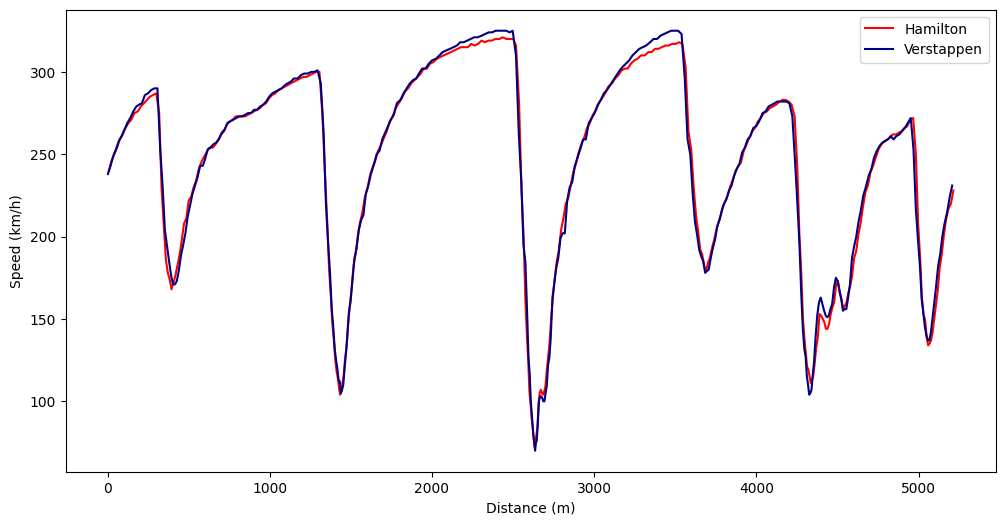

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(ham_tel['Distance'], ham_tel['Speed'], color='red', label='Hamilton')
plt.plot(ver_tel['Distance'], ver_tel['Speed'], color='navy', label='Verstappen')

plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.legend()
plt.show()

### Conclusion

**Straight line speed:** Verstappen (Blue) achieved slightly higher top speeds on the long straight. This highlights the Red Bull's aerodynamic efficiency and Honda's power unit deployment in the 2021 finale.

**Braking and corner entry:** Hamilton (Red) appears to hold his speed slightly longer into the heavy braking zones, suggesting a more aggressive braking approach or higher downforce confidence in specific slow-speed corners.

**Marginal Gains:** It shows how incredibly close these two drivers were in 2021. The tiny "gaps" at the peaks of the speed curves represent the fraction of a second that determined the pole position.